In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

# Read

In [5]:
df = pd.read_parquet('/Users/krispred/Documents/capstone/datascience-capstone/data/processed/particle_labeled.parquet')

In [6]:
df.head()

,stub_id,particle_id,relevance_class,ac,ag,al,ar,as,at,au,...,v,w,xe,y,yb,zn,zr,merged_relevance_class,final_class,label
0,22,1454,PbSb,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSb,PbSb,GSR
1,22,1274,PbSbBa,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSbBa,PbBaSb,GSR
2,22,275,PbSbBa,0.0,0.0,0.751013,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSbBa,PbBaSb,GSR
3,22,714,PbSbBa,0.0,0.0,0.824510,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSbBa,PbBaSb,GSR
4,22,2887,PbSb,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSb,PbSb,GSR


In [34]:
for col in df.columns:
    print(col, '\n')

stub_id 

particle_id 

relevance_class 

ac 

ag 

al 

ar 

as 

at 

au 

b 

ba 

bi 

br 

ca 

cd 

ce 

cl 

co 

cr 

cs 

cu 

dy 

er 

eu 

f 

fe 

fr 

ga 

gd 

ge 

hf 

hg 

ho 

i 

in 

ir 

k 

kr 

la 

lu 

mg 

mn 

mo 

n 

na 

nb 

nd 

ne 

ni 

np 

o 

os 

p 

pa 

pb 

pd 

pm 

po 

pr 

pt 

pu 

ra 

rb 

re 

rh 

rn 

ru 

s 

sb 

sc 

se 

si 

sm 

sn 

sr 

ta 

tb 

tc 

te 

th 

ti 

tl 

tm 

u 

v 

w 

xe 

y 

yb 

zn 

zr 

merged_relevance_class 

final_class 

label 



In [11]:
element_cols = [c for c in df.columns if c not in [
    'stub_id', 'particle_id', 'relevance_class',
    'merged_relevance_class', 'final_class', 'label', 'target'
] and df[c].dtype in ['float64', 'int64']]

print(f"Particles: {len(df):,}")
print(f"Element features: {len(element_cols)}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())

Particles: 2,801,667
Element features: 89

Label distribution:
label
Non_GSR      1216039
GSR          1078946
Ambiguous     506682
Name: count, dtype: int64


# This data is sparse as most elemental cols are 0 (trees can handle this) but how sparse?

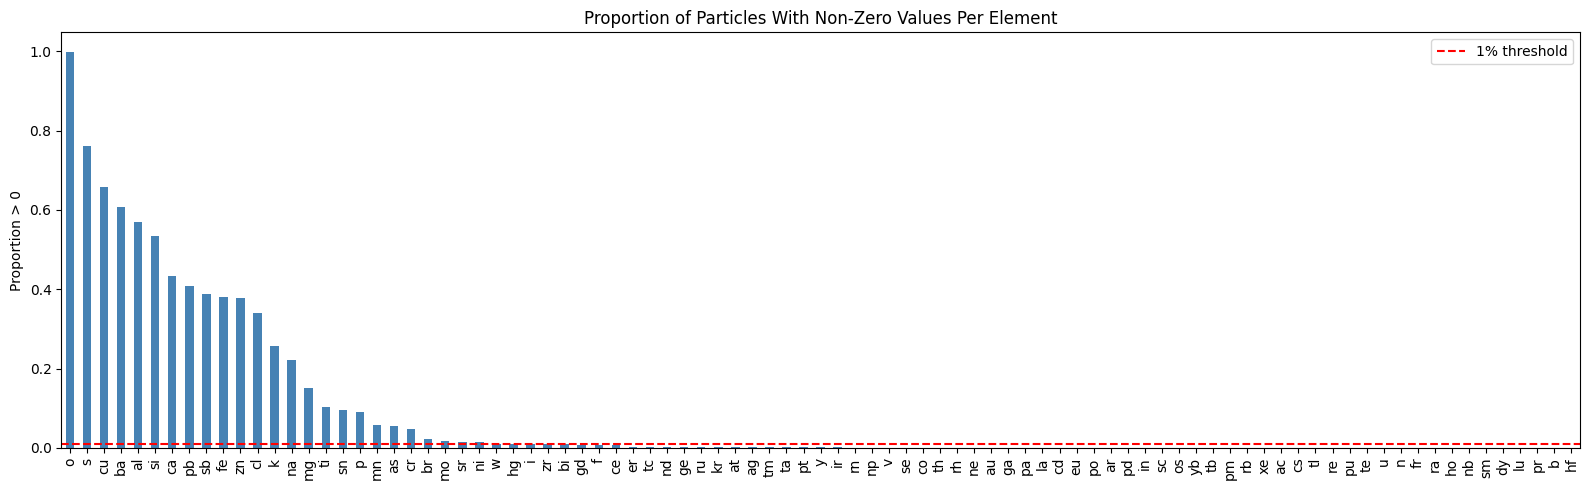

In [13]:
nonzero_rates = (df[element_cols] > 0).mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16, 5))
nonzero_rates.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Proportion of Particles With Non-Zero Values Per Element')
ax.set_ylabel('Proportion > 0')
ax.axhline(y=0.01, color='red', linestyle='--', label='1% threshold')
ax.legend()
plt.tight_layout()
#plt.savefig('figures/element_sparsity.png', bbox_inches='tight')
plt.show()

In [14]:
informative = nonzero_rates[nonzero_rates > 0.01].index.tolist()
sparse = nonzero_rates[nonzero_rates <= 0.01].index.tolist()
print(f"\nInformative elements (>1% non-zero): {len(informative)}")
print(informative)
print(f"\nSparse elements (<=1% non-zero): {len(sparse)}")
print(sparse)


Informative elements (>1% non-zero): 27
['o', 's', 'cu', 'ba', 'al', 'si', 'ca', 'pb', 'sb', 'fe', 'zn', 'cl', 'k', 'na', 'mg', 'ti', 'sn', 'p', 'mn', 'as', 'cr', 'br', 'mo', 'sr', 'ni', 'w', 'hg']

Sparse elements (<=1% non-zero): 62
['i', 'zr', 'bi', 'gd', 'f', 'ce', 'er', 'tc', 'nd', 'ge', 'ru', 'kr', 'at', 'ag', 'tm', 'ta', 'pt', 'y', 'ir', 'rn', 'np', 'v', 'se', 'co', 'th', 'rh', 'ne', 'au', 'ga', 'pa', 'la', 'cd', 'eu', 'po', 'ar', 'pd', 'in', 'sc', 'os', 'yb', 'tb', 'pm', 'rb', 'xe', 'ac', 'cs', 'tl', 're', 'pu', 'te', 'u', 'n', 'fr', 'ra', 'ho', 'nb', 'sm', 'dy', 'lu', 'pr', 'b', 'hf']


# What is the average elemental composition per particle? 

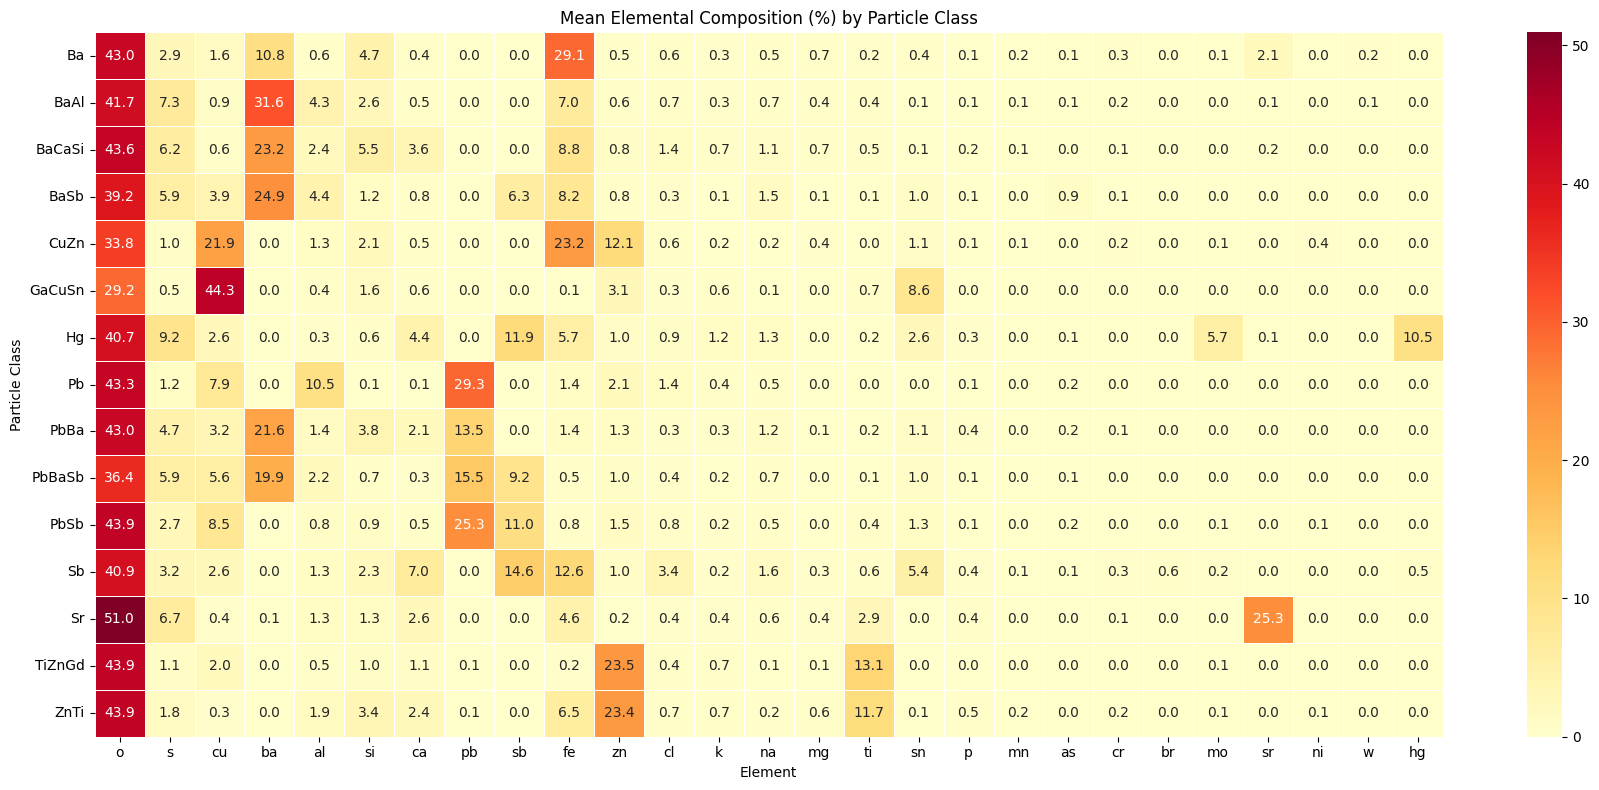

In [15]:
class_means = df.groupby('final_class')[informative].mean()

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(class_means, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5)
ax.set_title('Mean Elemental Composition (%) by Particle Class')
ax.set_ylabel('Particle Class')
ax.set_xlabel('Element')
plt.tight_layout()
#plt.savefig('figures/class_composition_heatmap.png', bbox_inches='tight')
plt.show()

# How balanced is our data?

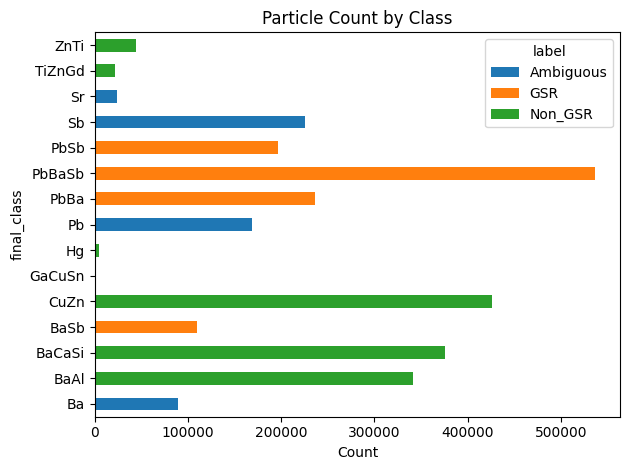

In [19]:
class_counts = df.groupby(['final_class', 'label']).size().unstack(fill_value=0)

class_counts.plot(kind='barh', stacked=True)
plt.title('Particle Count by Class')
plt.xlabel('Count')

plt.tight_layout()
#plt.savefig('figures/class_balance.png', bbox_inches='tight')
plt.show()

# How strong is the signal? 

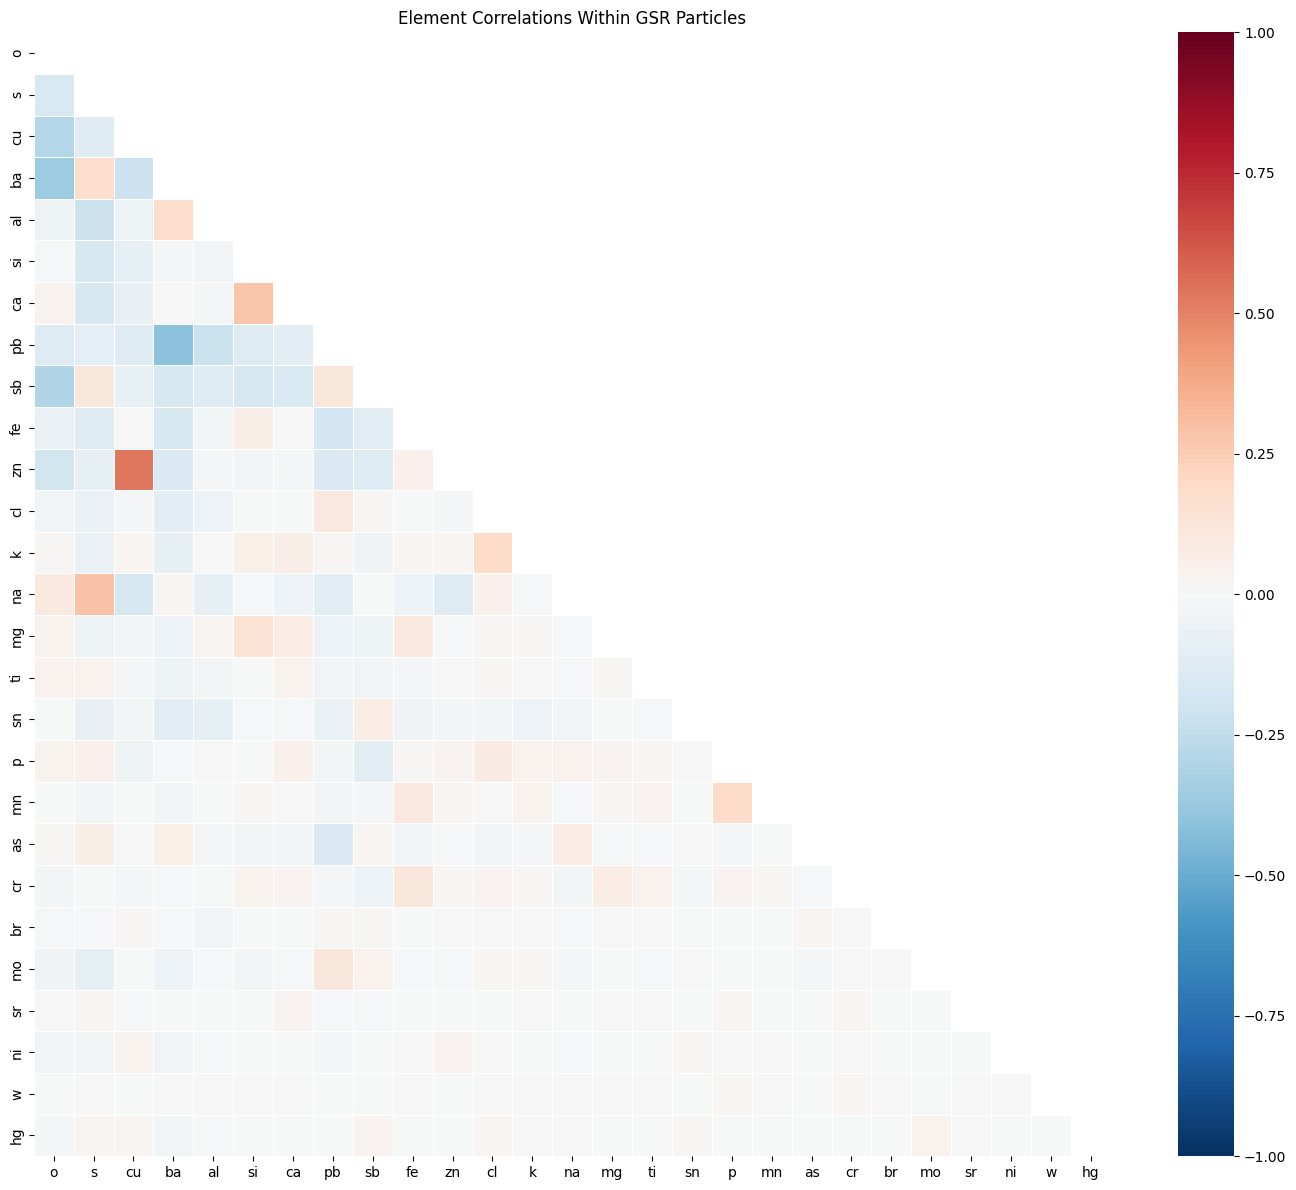

In [20]:
gsr_only = df[df['label'] == 'GSR'][informative]

corr = gsr_only.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=False, ax=ax, linewidths=0.5)
ax.set_title('Element Correlations Within GSR Particles')
plt.tight_layout()
#plt.savefig('figures/correlation_gsr.png', bbox_inches='tight')
plt.show()

In [21]:
corr_pairs = corr.where(~mask).stack().reset_index()
corr_pairs.columns = ['elem1', 'elem2', 'correlation']
corr_pairs['abs_corr'] = corr_pairs['correlation'].abs()
print("Strongest correlations among GSR particles:")
print(corr_pairs.nlargest(10, 'abs_corr').to_string(index=False))

Strongest correlations among GSR particles:
elem1 elem2  correlation  abs_corr
   zn    cu     0.535134  0.535134
   pb    ba    -0.407388  0.407388
   ba     o    -0.360674  0.360674
   sb     o    -0.301122  0.301122
   na     s     0.292367  0.292367
   cu     o    -0.290601  0.290601
   ca    si     0.280147  0.280147
   pb    al    -0.221327  0.221327
   ba    cu    -0.217829  0.217829
   al     s    -0.215863  0.215863


# Is PCA helpful? We have sparse data so maybe not.

In [28]:
le = LabelEncoder()

In [24]:
binary = df[df['label'].isin(['GSR', 'Non_GSR'])]

In [29]:
class_encoded = le.fit_transform(binary['final_class'])

In [25]:
X_vis = binary[informative].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vis)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

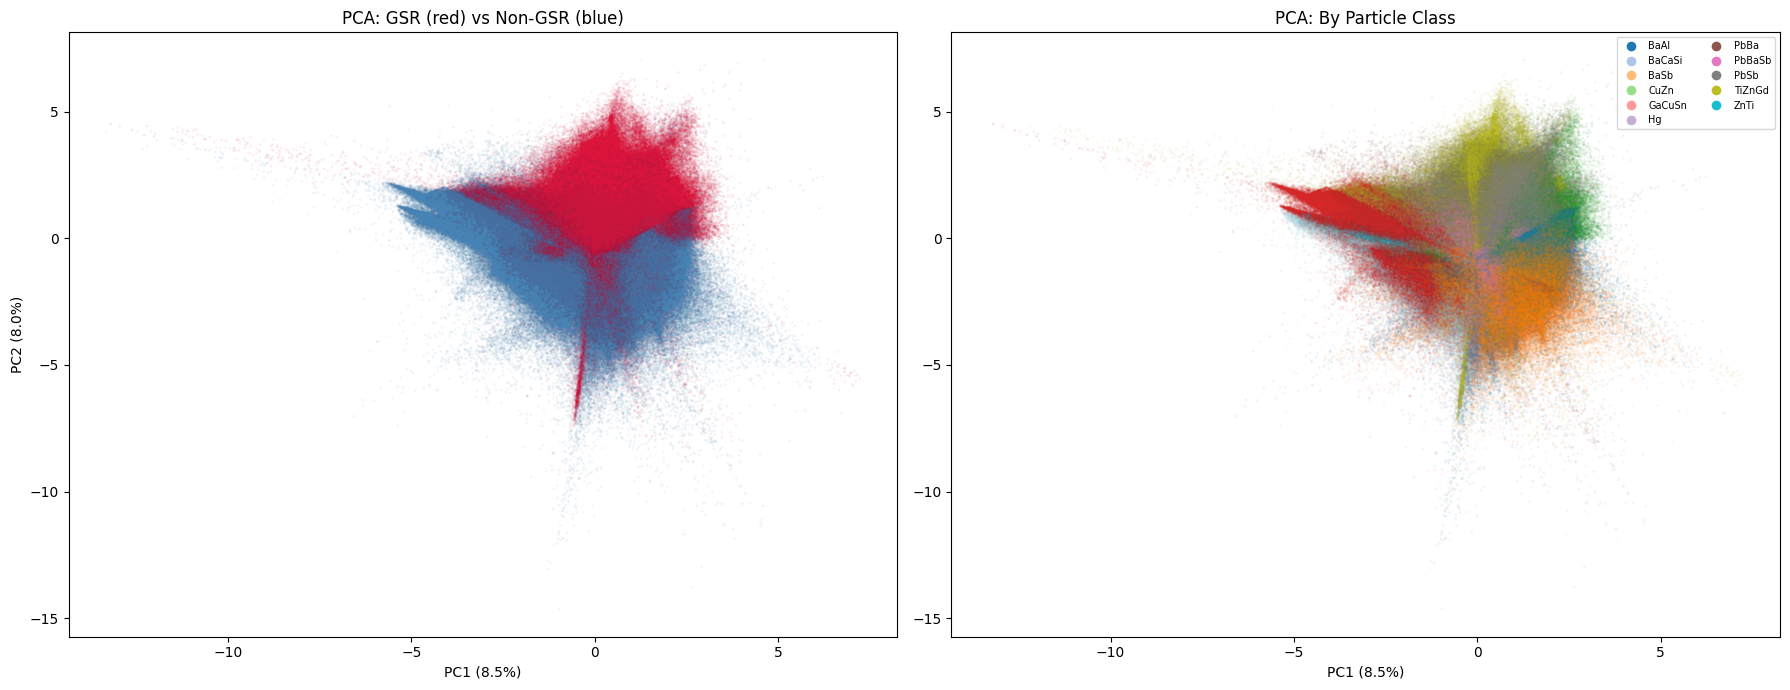

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors = binary['label'].map({'GSR': 'crimson', 'Non_GSR': 'steelblue'}).values
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.05, s=1)
axes[0].set_title('PCA: GSR (red) vs Non-GSR (blue)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=class_encoded,
                           cmap='tab20', alpha=0.05, s=1)
axes[1].set_title('PCA: By Particle Class')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')

handles = [plt.Line2D([0], [0], marker='o', color='w',
           markerfacecolor=plt.cm.tab20(i / len(le.classes_)),
           markersize=8, label=cls)
           for i, cls in enumerate(le.classes_)]
axes[1].legend(handles=handles, loc='upper right', fontsize=7,
               ncol=2, markerscale=1)

plt.tight_layout()
#plt.savefig('figures/pca_visualization.png', bbox_inches='tight')
plt.show()

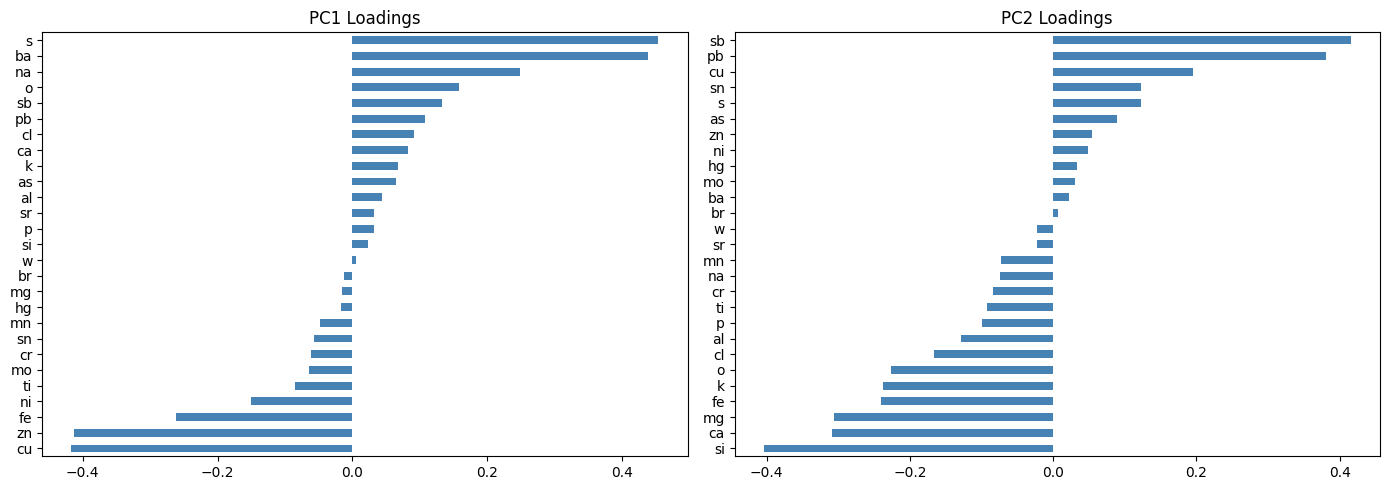

In [31]:
# PCA loadings: which elements define the principal components?
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=informative
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
loadings['PC1'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('PC1 Loadings')
loadings['PC2'].sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('PC2 Loadings')
plt.tight_layout()
#plt.savefig('figures/pca_loadings.png', bbox_inches='tight')
plt.show()

# What is up with the ambiguous particles? Is there clear separation? 

In [32]:
ambiguous = df[df['label'] == 'Ambiguous']
X_amb = scaler.transform(ambiguous[informative].fillna(0).values)
X_amb_pca = pca.transform(X_amb)

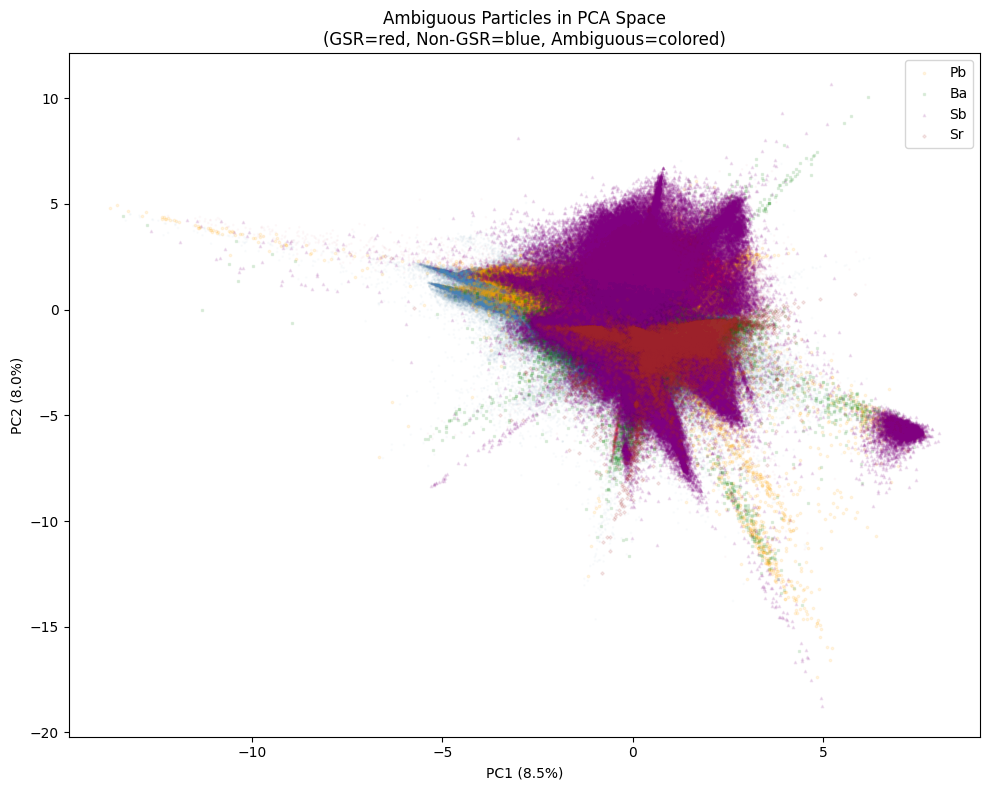

In [33]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.02, s=1)

for cls, color, marker in [('Pb', 'orange', 'o'), ('Ba', 'green', 's'),
                            ('Sb', 'purple', '^'), ('Sr', 'brown', 'D')]:
    mask = ambiguous['final_class'] == cls
    if mask.sum() > 0:
        ax.scatter(X_amb_pca[mask, 0], X_amb_pca[mask, 1],
                   c=color, s=3, alpha=0.1, label=cls, marker=marker)

ax.legend(fontsize=10)
ax.set_title('Ambiguous Particles in PCA Space\n(GSR=red, Non-GSR=blue, Ambiguous=colored)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.tight_layout()
#plt.savefig('figures/pca_ambiguous.png', bbox_inches='tight')
plt.show()

# Summary Stats

In [38]:
print(f"\nPCA variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}")


PCA variance explained: PC1=8.5%, PC2=8.0%


### Interpretation
PC1 and PC2 together explain only 16.5% of variance (8.5% + 8.0%). The scatter plots show substantial overlap between GSR and Non-GSR particles in the reduced space.

This has important implications:
- Linear models (logistic regression) will struggle as there's no clean linear separation
- High-dimensional feature space is necessary and dimensionality reduction loses critical information